In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from utils import ResonanceFitData, PendulumsData, save_plot, bar_chart

In [2]:
lengths = np.array([0.97, 0.99, 0.995, 1.0])
labels = ["97cm", "99cm", "99.5cm", "100cm"]

# tests
# lengths = np.array([1.01, 1.0, 0.995, 0.99])
# labels = ["101cm", "100cm", "99.5cm", "99cm"]

cols = ["mass A", "mass B", "mass C", "mass D"]
L_d = 1.0

In [3]:
increased_mass = PendulumsData(
    cols, labels, lengths, 
    pd.read_csv("../data/session-6/increased-mass.csv").dropna()
)
doubled_mass = PendulumsData(
    cols, labels, lengths, 
    pd.read_csv("../data/session-6/doubled-mass.csv").dropna()
)
short_dress = PendulumsData(
    cols, labels, lengths, 
    pd.read_csv("../data/session-6/short-skirt.csv").dropna()
)
long_dress = PendulumsData(
    cols, labels, lengths, 
    pd.read_csv("../data/session-6/long-skirt.csv").dropna()
)

In [4]:
# remove origin axis differences
increased_mass.preprocess_offsets()
doubled_mass.preprocess_offsets()
short_dress.preprocess_offsets()
long_dress.preprocess_offsets()

In [5]:
increased_mass_fit = ResonanceFitData(L_d, increased_mass)
doubled_mass_fit = ResonanceFitData(L_d, doubled_mass)
short_dress_fit = ResonanceFitData(L_d, short_dress)
long_dress_fit = ResonanceFitData(L_d, long_dress)

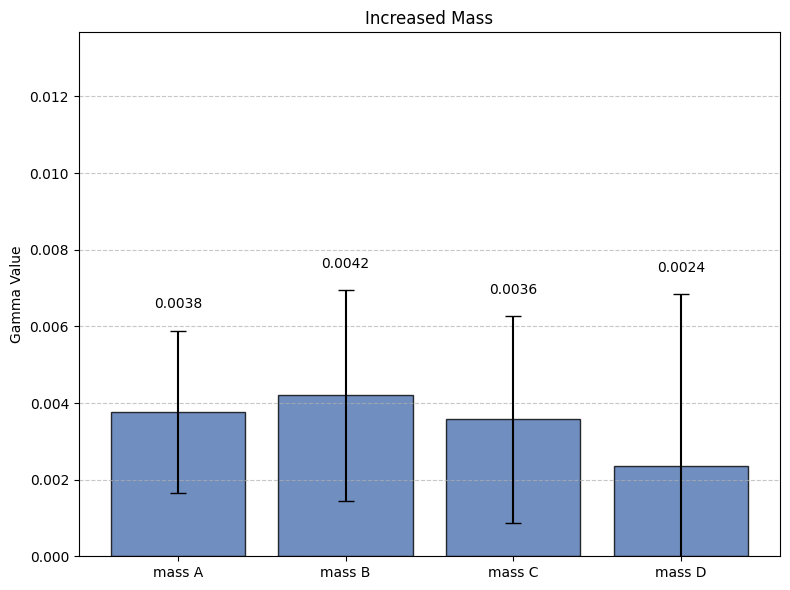

In [6]:
increased_mass_fit.fit_single_pendulums()

data_to_plot: tuple[list[str], list[float], list[float]] = ([], [], [])

for col in increased_mass_fit.envelope_data.cols:
    gamma, gamma_err = increased_mass_fit.single_pendulum_gamma[col]
    data_to_plot[0].append(col)
    data_to_plot[1].append(gamma)
    data_to_plot[2].append(gamma_err)    

bar_chart(data_to_plot, title="Increased Mass")

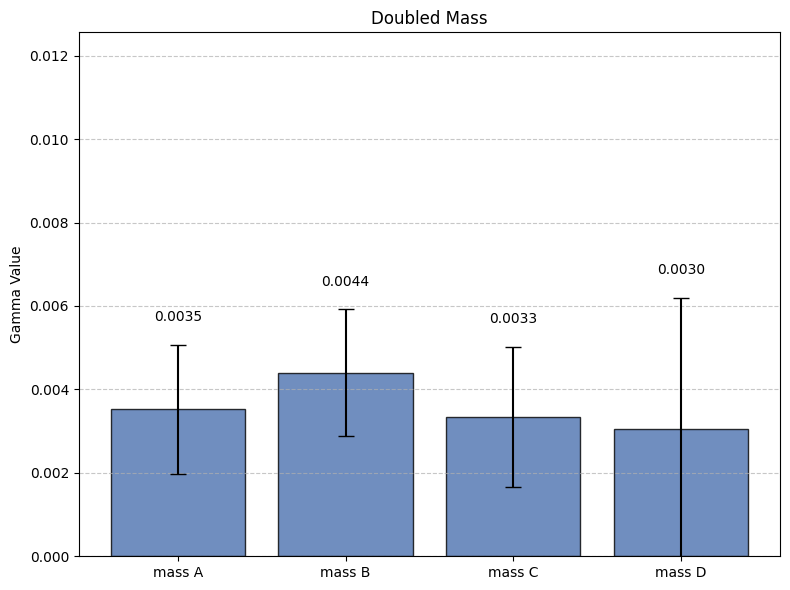

In [7]:
doubled_mass_fit.fit_single_pendulums()

data_to_plot: tuple[list[str], list[float], list[float]] = ([], [], [])

for col in doubled_mass_fit.envelope_data.cols:
    gamma, gamma_err = doubled_mass_fit.single_pendulum_gamma[col]
    data_to_plot[0].append(col)
    data_to_plot[1].append(gamma)
    data_to_plot[2].append(gamma_err)    

bar_chart(data_to_plot, title="Doubled Mass")

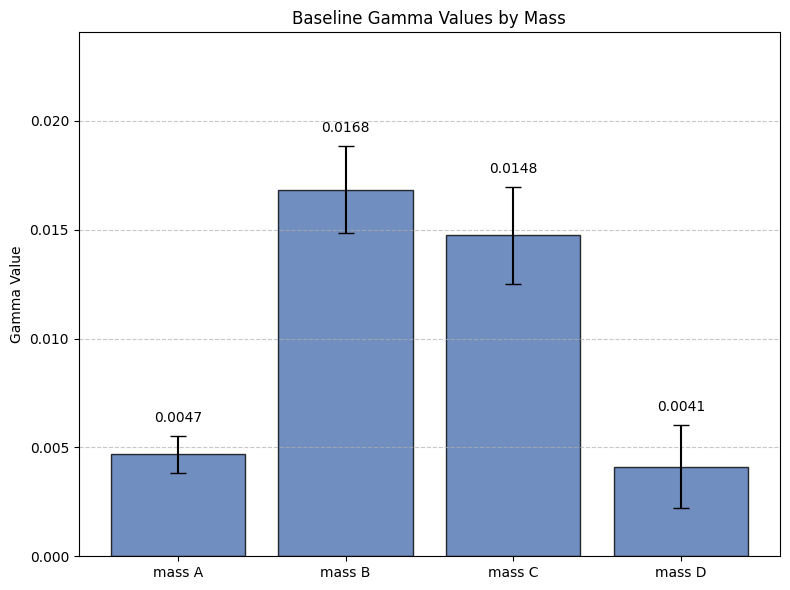

In [8]:
short_dress_fit.fit_single_pendulums()

data_to_plot: tuple[list[str], list[float], list[float]] = ([], [], [])

for col in short_dress_fit.envelope_data.cols:
    gamma, gamma_err = short_dress_fit.single_pendulum_gamma[col]
    data_to_plot[0].append(col)
    data_to_plot[1].append(gamma)
    data_to_plot[2].append(gamma_err)    

bar_chart(data_to_plot)

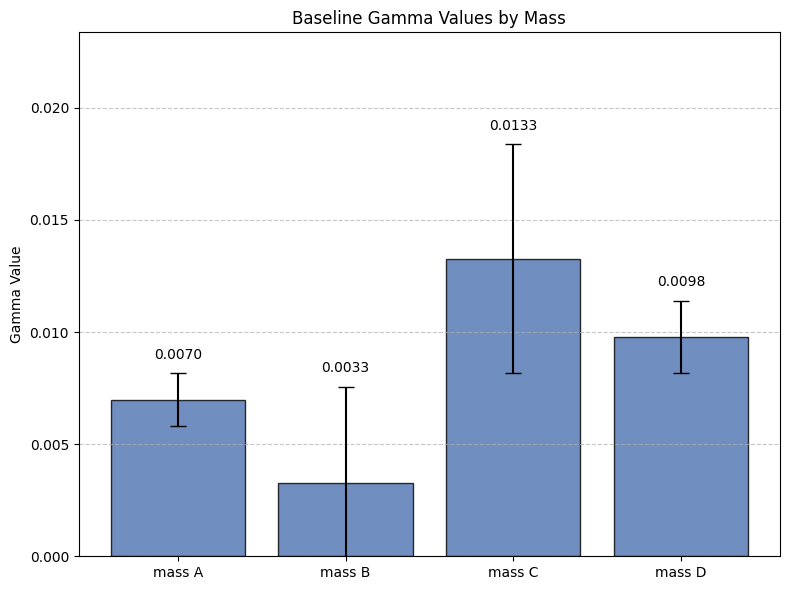

In [9]:
long_dress_fit.fit_single_pendulums()

data_to_plot: tuple[list[str], list[float], list[float]] = ([], [], [])

for col in long_dress_fit.envelope_data.cols:
    gamma, gamma_err = long_dress_fit.single_pendulum_gamma[col]
    data_to_plot[0].append(col)
    data_to_plot[1].append(gamma)
    data_to_plot[2].append(gamma_err)    

bar_chart(data_to_plot)